# PM2.5 Forecasting Using SARIMAX (with O₃)
This model extends SARIMA by incorporating O₃ as an exogenous predictor.
Target variable: PM25  
Exogenous variable: O3  
Train: 2020–2022  
Test: 2023

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

path = "../../data/processed/pm25_o3_merged.csv"
df = pd.read_csv(path)

df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["City", "Date"]).reset_index(drop=True)

print(df.columns)
df.head()

Index(['City', 'Date', 'PM25_daily', 'Year_x', 'Month_x', 'O3_daily', 'Year_y',
       'Month_y', 'Year', 'Month', 'Season'],
      dtype='object')


,City,Date,PM25_daily,Year_x,Month_x,O3_daily,Year_y,Month_y,Year,Month,Season
0,Agassiz,2020-01-01,0.666667,2020,1,38.208333,2020,1,2020,1,Winter
1,Agassiz,2020-01-02,1.291667,2020,1,29.791667,2020,1,2020,1,Winter
2,Agassiz,2020-01-03,1.333333,2020,1,15.291667,2020,1,2020,1,Winter
3,Agassiz,2020-01-04,3.791667,2020,1,30.791667,2020,1,2020,1,Winter
4,Agassiz,2020-01-05,4.291667,2020,1,17.375000,2020,1,2020,1,Winter


In [3]:
df = df.rename(columns={
    "PM25_daily": "PM25",
    "O3_daily": "O3"
})

print("Final columns:", df.columns.tolist())

Final columns: ['City', 'Date', 'PM25', 'Year_x', 'Month_x', 'O3', 'Year_y', 'Month_y', 'Year', 'Month', 'Season']


In [4]:
df = df[["City", "Date", "PM25", "O3", "Season"]]

## Time-Based Split
We use chronological splitting to avoid data leakage.

Train: 2020–2022  
Test: 2023

In [6]:
top_cities = df["City"].value_counts().head(10).index.tolist()
cutoff = pd.Timestamp("2023-01-01")
top_cities

['Metro Van - North Vancouver',
 'Red Deer',
 'Fort Mcmurray',
 'Gibbons',
 'Grande Prairie',
 'Sault Ste. Marie',
 'Hamilton',
 'Saint John',
 'Quebec',
 'Calgary']

# SARIMAX Per City

In [8]:
results = []
forecast_store = {}

for city in top_cities:
    print(f"\n=== City: {city} ===")

    city_df = df[df["City"] == city].copy().sort_values("Date")
    city_df = city_df.set_index("Date").asfreq("D")

    y_train = city_df.loc[city_df.index < cutoff, "PM25"]
    y_test  = city_df.loc[city_df.index >= cutoff, "PM25"]

    exog_train = city_df.loc[city_df.index < cutoff, ["O3"]]
    exog_test  = city_df.loc[city_df.index >= cutoff, ["O3"]]

    train_block = pd.concat([y_train, exog_train], axis=1).dropna()
    test_block  = pd.concat([y_test, exog_test], axis=1).dropna()

    y_train = train_block["PM25"]
    exog_train = train_block[["O3"]]

    y_test = test_block["PM25"]
    exog_test = test_block[["O3"]]

    if len(y_train) < 200 or len(y_test) < 60:
        print("Skipping due to insufficient data.")
        continue

    try:
        model = SARIMAX(
            y_train,
            exog=exog_train,
            order=(1,1,1),
            seasonal_order=(1,1,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        y_pred = model.forecast(steps=len(y_test), exog=exog_test)
        y_pred = pd.Series(y_pred, index=y_test.index)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append({
            "City": city,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "AIC": model.aic
        })

        forecast_store[city] = (y_test, y_pred)

        print(f"MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.3f}")

    except Exception as e:
        print("Failed:", e)


=== City: Metro Van - North Vancouver ===
MAE=2.854, RMSE=5.562, R2=-0.056

=== City: Red Deer ===
MAE=8.592, RMSE=20.279, R2=-0.157

=== City: Fort Mcmurray ===
MAE=17.368, RMSE=43.405, R2=-0.160

=== City: Gibbons ===
MAE=11.769, RMSE=26.018, R2=-0.059

=== City: Grande Prairie ===
MAE=13.268, RMSE=36.247, R2=-0.130

=== City: Sault Ste. Marie ===
MAE=3.932, RMSE=11.390, R2=-0.000

=== City: Hamilton ===
MAE=5.071, RMSE=7.933, R2=-0.127

=== City: Saint John ===
MAE=2.329, RMSE=3.335, R2=-0.136

=== City: Quebec ===
MAE=3.885, RMSE=6.555, R2=-0.040

=== City: Calgary ===
MAE=7.868, RMSE=16.587, R2=-0.104


In [9]:
results_df = pd.DataFrame(results).sort_values("MAE")
results_df.to_csv("../../outputs_PM25_SARIMAX_O3_results.csv", index=False)

print("Saved: outputs_PM25_SARIMAX_O3_results.csv")
results_df

Saved: outputs_PM25_SARIMAX_O3_results.csv


,City,MAE,RMSE,R2,AIC
7,Saint John,2.329286,3.334994,-0.135619,5123.043631
0,Metro Van - North Vancouver,2.854216,5.562491,-0.055980,6720.996604
8,Quebec,3.884724,6.555150,-0.040244,6044.864794
5,Sault Ste. Marie,3.931856,11.389734,-0.000296,5443.376020
6,Hamilton,5.070553,7.932640,-0.126891,6367.919830
9,Calgary,7.867674,16.587271,-0.103950,6862.607503
1,Red Deer,8.591628,20.279204,-0.157391,6337.121999
3,Gibbons,11.768892,26.017519,-0.059172,7462.383414
4,Grande Prairie,13.268310,36.246517,-0.129645,6138.813812
2,Fort Mcmurray,17.367676,43.404873,-0.160381,6180.207996


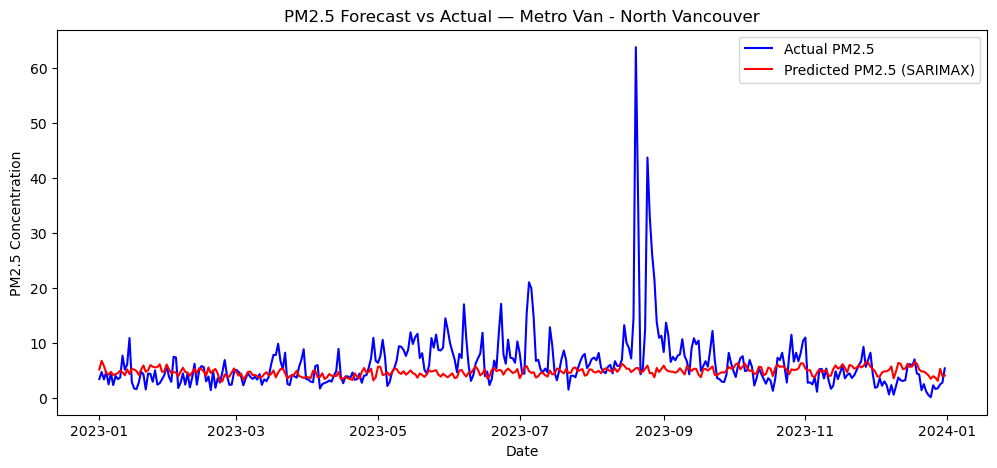

In [10]:
example_city = list(forecast_store.keys())[0]

y_test_example, y_pred_example = forecast_store[example_city]

plt.figure(figsize=(12,5))
plt.plot(y_test_example.index, y_test_example, label="Actual PM2.5", color="blue")
plt.plot(y_pred_example.index, y_pred_example, label="Predicted PM2.5 (SARIMAX)", color="red")

plt.title(f"PM2.5 Forecast vs Actual — {example_city}")
plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")
plt.legend()

plt.savefig("figure6_forecast_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()